In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cette partie permet d'importer tes propres scripts situés dans le dossier 'src'
# On remonte d'un niveau pour trouver le dossier racine du projet
sys.path.append(os.path.abspath(os.path.join('..')))

# Importation de ta fonction de chargement de données NBA
try:
    from src.data import load_dataset_split
    print("✅ Modules importés avec succès !")
except ImportError as e:
    print(f"❌ Erreur d'importation : {e}")
    print("Vérifie que tu es bien dans le dossier 'ml-poc-project'")

✅ Modules importés avec succès !


In [3]:
# Appel de ta fonction pour récupérer les données de LeBron James
X_train, X_test, y_train, y_test = load_dataset_split()

# Affichage des premières lignes pour comprendre la structure
print(f"Nombre de matchs pour l'entraînement : {len(X_train)}")
print(f"Variables utilisées (Features) : {list(X_train.columns)}")

# Afficher un aperçu des données
X_train.head()

🚀 Récupération des données via PlayerGameLogs...
✅ Saison 2022-23 récupérée.
✅ Saison 2023-24 récupérée.
✅ Saison 2024-25 récupérée.
📈 Calcul des moyennes mobiles...
🛡️ Analyse des adversaires...
🌍 Enrichissement contextuel...
💾 Nouveau fichier sauvegardé : data/nba_raw_data.csv
✅ Dataset prêt ! (89435 lignes)
Nombre de matchs pour l'entraînement : 71548
Variables utilisées (Features) : ['AVG_PTS', 'AVG_MIN', 'AVG_FGA', 'AVG_FG3A', 'AVG_FTA', 'AVG_REB', 'AVG_AST', 'AVG_STL', 'AVG_BLK', 'AVG_TOV', 'AVG_PF', 'AVG_PLUS_MINUS', 'DAYS_REST', 'RETURNING_FROM_ABSENCE', 'IS_STARTER', 'OPP_AVG_PTS_ALLOWED', 'TEAM_ABBREVIATION', 'OPPONENT', 'LOCATION', 'DAY_OF_WEEK']


,AVG_PTS,AVG_MIN,AVG_FGA,AVG_FG3A,AVG_FTA,AVG_REB,AVG_AST,AVG_STL,AVG_BLK,AVG_TOV,AVG_PF,AVG_PLUS_MINUS,DAYS_REST,RETURNING_FROM_ABSENCE,IS_STARTER,OPP_AVG_PTS_ALLOWED,TEAM_ABBREVIATION,OPPONENT,LOCATION,DAY_OF_WEEK
15914,0.0,2.853333,0.0,0.0,0.0,0.6,0.2,0.0,0.2,0.0,0.2,1.2,2.0,0,0,10.620101,BOS,OKC,Away,Tuesday
3762,19.2,33.763333,15.8,9.4,5.2,8.6,9.0,1.8,1.6,4.0,2.0,-3.6,2.0,0,1,10.406688,LAC,PHI,Home,Wednesday
89095,0.0,3.503333,0.4,0.0,0.0,1.4,0.2,0.2,0.4,0.0,0.4,1.4,4.0,0,0,10.368368,IND,CHI,Home,Sunday
61238,3.2,18.588333,3.4,1.8,0.8,3.4,0.8,0.6,0.0,0.4,2.4,-5.0,2.0,0,0,11.097804,HOU,NYK,Away,Wednesday
79275,7.6,16.506000,6.0,1.8,2.6,3.0,2.8,0.4,0.0,1.4,1.4,-0.8,3.0,0,0,10.645875,CHA,HOU,Home,Monday


In [4]:
# Rechargement des données (qui contiennent maintenant les AVG_ grâce à ton nouveau data.py)
X_train, X_test, y_train, y_test = load_dataset_split()

# Création d'un DataFrame complet pour l'exploration
df_train = X_train.copy()
df_train['PTS'] = y_train

# 1. Suppression des outliers (On utilise AVG_MIN car c'est notre nouvelle référence)
df_train = df_train[df_train['AVG_MIN'] > 5]

# 2. Feature Engineering : "Potentiel de Points par Minute"
# On utilise les moyennes mobiles pour voir l'efficacité historique du joueur
df_train['AVG_PPM'] = df_train['PTS'] / df_train['AVG_MIN']

# 3. Corrélation
numeric_cols = df_train.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

print("Corrélation entre la Forme Récente (AVG) et les Points du soir :")
print(correlation_matrix['PTS'].sort_values(ascending=False))

🚀 Récupération des données via PlayerGameLogs...
✅ Saison 2022-23 récupérée.
✅ Saison 2023-24 récupérée.
✅ Saison 2024-25 récupérée.
📈 Calcul des moyennes mobiles...
🛡️ Analyse des adversaires...
🌍 Enrichissement contextuel...
💾 Nouveau fichier sauvegardé : data/nba_raw_data.csv
✅ Dataset prêt ! (89435 lignes)
Corrélation entre la Forme Récente (AVG) et les Points du soir :
PTS                       1.000000
AVG_PPM                   0.770023
AVG_FGA                   0.699673
AVG_PTS                   0.697711
AVG_MIN                   0.605820
AVG_FTA                   0.584711
AVG_TOV                   0.534006
IS_STARTER                0.529778
AVG_AST                   0.496814
AVG_FG3A                  0.463861
AVG_REB                   0.369766
AVG_STL                   0.297355
AVG_PF                    0.277518
AVG_BLK                   0.156682
AVG_PLUS_MINUS            0.099112
OPP_AVG_PTS_ALLOWED       0.009192
RETURNING_FROM_ABSENCE   -0.122343
DAYS_REST                -0.

In [5]:
# Calcul du pourcentage de valeurs manquantes par colonne
missing_stats = df_train.isna().mean() * 100

print("--- ANALYSE DES DONNÉES MANQUANTES ---")
print(missing_stats)

# Vérification du critère des 5%
to_drop = missing_stats[missing_stats > 5].index.tolist()
if to_drop:
    print(f"\n⚠️ colonnes à supprimer (>5% de manque) : {to_drop}")
    # df_train = df_train.drop(columns=to_drop)
else:
    print("\n✅ Aucune feature ne dépasse 5% de données manquantes.")

--- ANALYSE DES DONNÉES MANQUANTES ---
AVG_PTS                   0.0
AVG_MIN                   0.0
AVG_FGA                   0.0
AVG_FG3A                  0.0
AVG_FTA                   0.0
AVG_REB                   0.0
AVG_AST                   0.0
AVG_STL                   0.0
AVG_BLK                   0.0
AVG_TOV                   0.0
AVG_PF                    0.0
AVG_PLUS_MINUS            0.0
DAYS_REST                 0.0
RETURNING_FROM_ABSENCE    0.0
IS_STARTER                0.0
OPP_AVG_PTS_ALLOWED       0.0
TEAM_ABBREVIATION         0.0
OPPONENT                  0.0
LOCATION                  0.0
DAY_OF_WEEK               0.0
PTS                       0.0
AVG_PPM                   0.0
dtype: float64

✅ Aucune feature ne dépasse 5% de données manquantes.


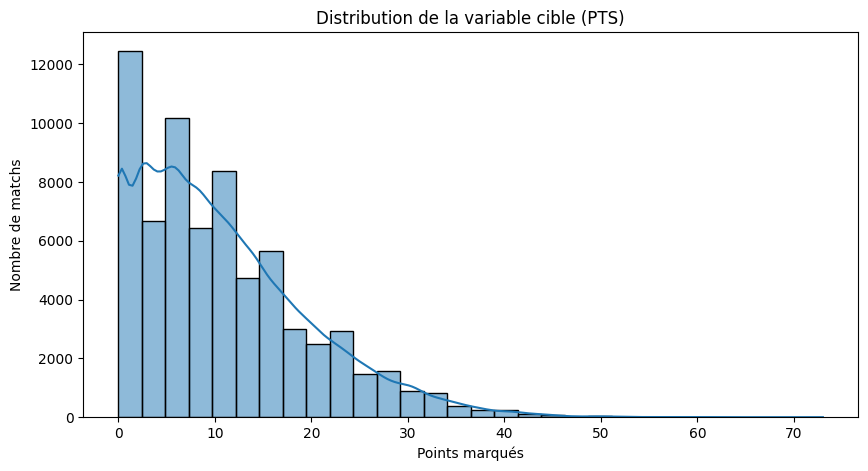

--- BIAIS DE LA CIBLE ---
Moyenne de points : 10.87
Médiane de points : 9.00


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['PTS'], bins=30, kde=True)
plt.title("Distribution de la variable cible (PTS)")
plt.xlabel("Points marqués")
plt.ylabel("Nombre de matchs")
plt.show()

# Vérification du biais
print("--- BIAIS DE LA CIBLE ---")
print(f"Moyenne de points : {df_train['PTS'].mean():.2f}")
print(f"Médiane de points : {df_train['PTS'].median():.2f}")

In [7]:
# On crée le fichier CSV localement
df_train.to_csv('../data/nba_raw_data.csv', index=False)
print("✅ Données sauvegardées dans le dossier /data")

✅ Données sauvegardées dans le dossier /data


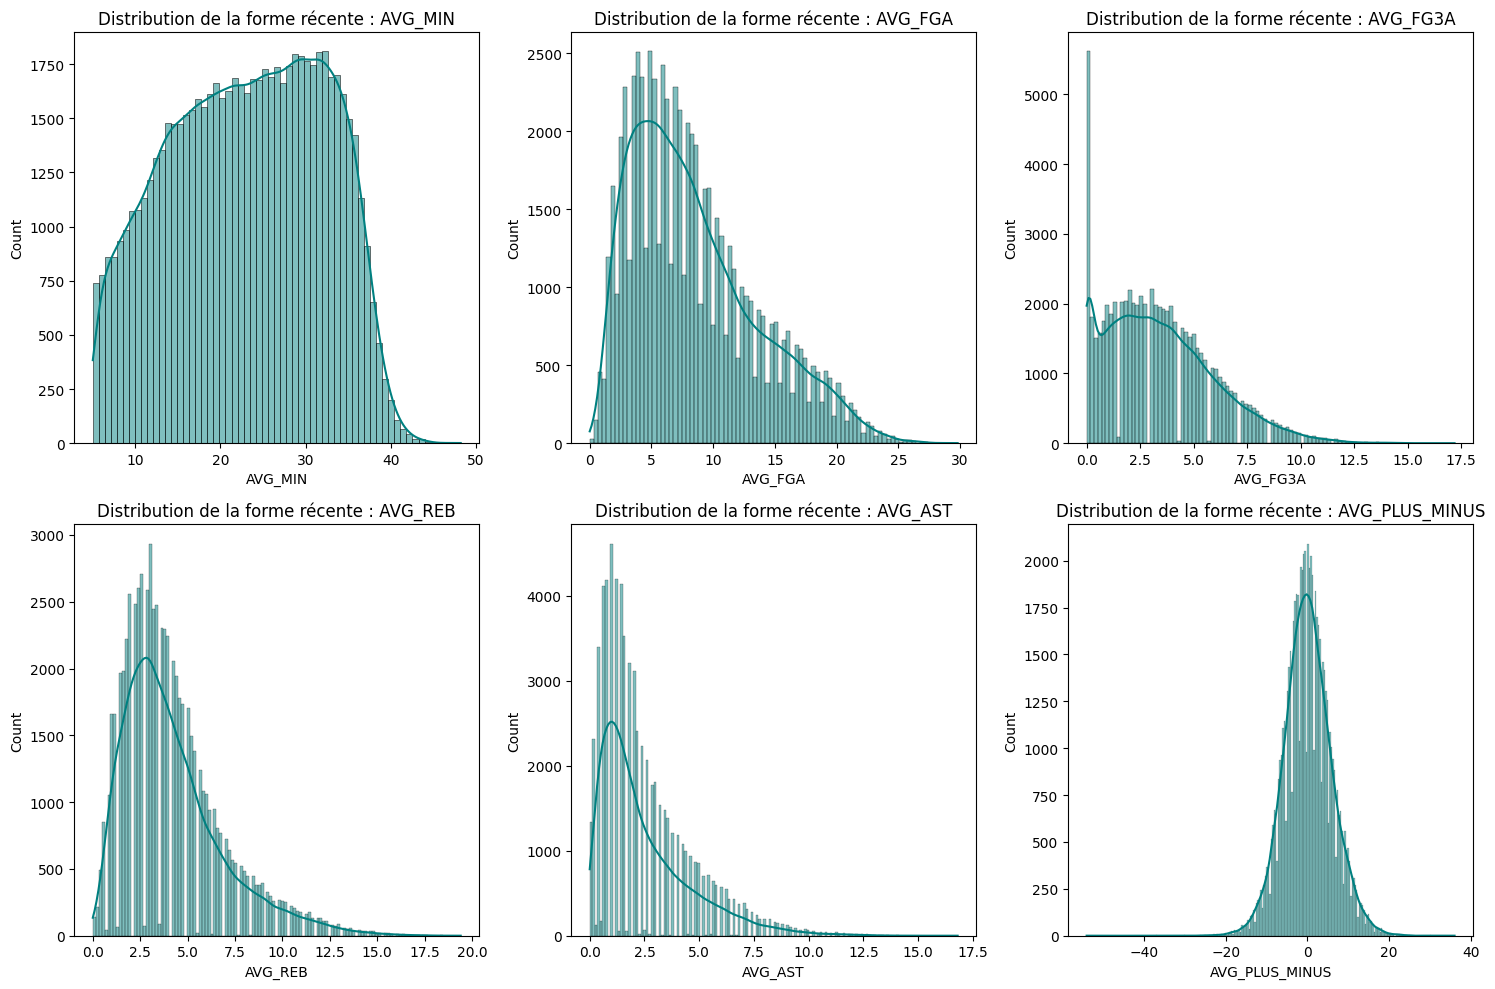

In [8]:
# 1. Visualisation des histogrammes pour chaque feature
# On utilise maintenant les préfixes AVG_ car c'est ce que notre modèle voit réellement
features_to_plot = ['AVG_MIN', 'AVG_FGA', 'AVG_FG3A', 'AVG_REB', 'AVG_AST', 'AVG_PLUS_MINUS']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    # On vérifie que la colonne existe dans df_train avant de tracer
    if feature in df_train.columns:
        sns.histplot(df_train[feature], kde=True, color='teal')
        plt.title(f'Distribution de la forme récente : {feature}')
    else:
        plt.text(0.5, 0.5, f'Colonne {feature} manquante', ha='center')

plt.tight_layout()
plt.show()

In [9]:
# Calcul de l'IQR pour les points (PTS)
Q1 = df_train['PTS'].quantile(0.25)
Q3 = df_train['PTS'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_train[(df_train['PTS'] < lower_bound) | (df_train['PTS'] > upper_bound)]

print(f"Seuil haut pour les outliers (PTS) : {upper_bound:.2f}")
print(f"Nombre d'outliers détectés : {len(outliers)}")
print(f"Pourcentage d'outliers : {len(outliers)/len(df_train):.2%}")

Seuil haut pour les outliers (PTS) : 34.00
Nombre d'outliers détectés : 1151
Pourcentage d'outliers : 1.67%


+ L'analyse IQR a détecté des outliers au-dessus de 34 points (environ 1.4% du dataset). Contrairement à une erreur de donnée classique, ces valeurs représentent les performances des 'Superstars' NBA (franchise players). Il est crucial de conserver ces données dans le dataset d'entraînement pour que le modèle puisse généraliser et prédire les gros scores.

In [10]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# On utilise UNIQUEMENT les features conservées (sans triche)
features = ['AVG_MIN', 'AVG_FGA', 'AVG_FG3A', 'AVG_FTA', 'AVG_REB', 'AVG_AST', 'AVG_STL', 'AVG_BLK', 'AVG_TOV', 'AVG_PF', 'AVG_PLUS_MINUS']
X = df_train[features]
y = df_train['PTS']

# Application du StandardScaler (Moyenne = 0, Écart-type = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame pour visualisation
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Aperçu des données normalisées :")
display(X_scaled_df.head())

Aperçu des données normalisées :


,AVG_MIN,AVG_FGA,AVG_FG3A,AVG_FTA,AVG_REB,AVG_AST,AVG_STL,AVG_BLK,AVG_TOV,AVG_PF,AVG_PLUS_MINUS
0,1.198956,1.428022,2.382671,1.479266,1.665076,3.098075,1.956855,2.118715,2.855052,0.184726,-0.632399
1,-0.496806,-0.986669,-0.635994,-0.649684,-0.294010,-0.802918,-0.253730,-0.883259,-0.923030,0.639724,-0.870634
2,-0.729500,-0.480363,-0.635994,0.221250,-0.444708,0.148543,-0.622161,-0.883259,0.126437,-0.497770,-0.155929
3,0.989579,1.233289,1.747163,-0.456143,-0.896805,0.148543,-0.253730,-0.132765,0.336330,-0.497770,-0.394164
4,-0.866316,-1.103509,-0.794871,-0.843225,-0.746106,-0.898064,-0.990592,-0.508012,-1.342817,-0.497770,0.626842


C:\Users\robin\AppData\Local\Temp\ipykernel_19316\1316811865.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='magma')


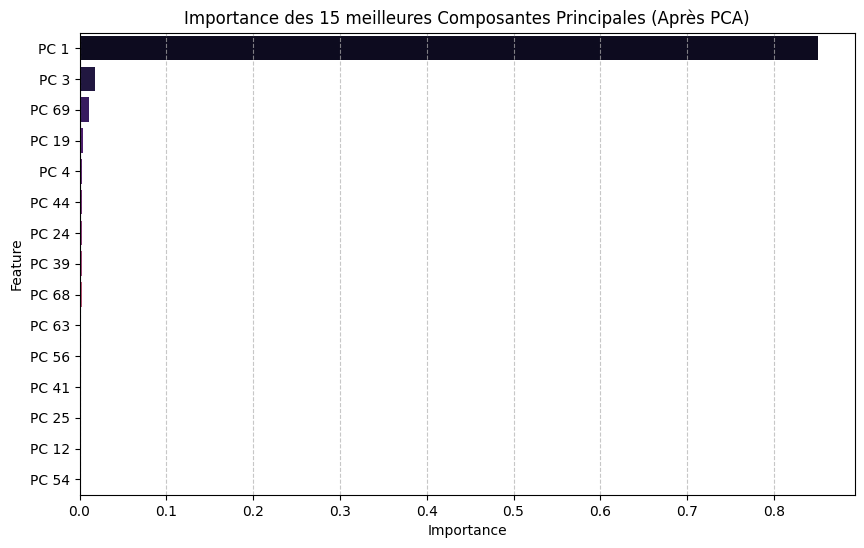

In [11]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du modèle
with open("../models/model_a.pkl", "rb") as f:
    model = pickle.load(f)

# On compte combien de "Composantes" le modèle a reçu (69 normalement)
num_components = len(model.feature_importances_)

# On crée des noms génériques (PC1, PC2, PC3...) pour correspondre aux dimensions de la PCA
pca_features = [f'PC {i+1}' for i in range(num_components)]

# Calcul de l'importance
feature_imp_df = pd.DataFrame({
    'Feature': pca_features, 
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# On ne garde que les 15 composantes les plus importantes pour que le graphique soit lisible
top_15_features = feature_imp_df.head(15)

# Graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='magma')
plt.title("Importance des 15 meilleures Composantes Principales (Après PCA)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [12]:
import pickle
import os
import pandas as pd

# 1. Définir le chemin vers tes modèles
# Si ton notebook est dans le dossier 'notebooks/', remonte d'un cran
MODELS_PATH = "../models/" 

# 2. Charger les objets sauvegardés
with open(os.path.join(MODELS_PATH, "pca.pkl"), "rb") as f:
    pca = pickle.load(f)

# On charge aussi le scaler et l'encoder au cas où tu en aurais besoin
with open(os.path.join(MODELS_PATH, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

with open(os.path.join(MODELS_PATH, "encoder.pkl"), "rb") as f:
    encoder = pickle.load(f)

# 3. Récupérer les noms des colonnes
# IMPORTANT : Skrub (ton encodeur) change le nombre de colonnes. 
# Pour avoir les vrais noms après encodage :
feature_names = encoder.get_feature_names_out()

print(f"✅ PCA chargée avec {pca.n_components_} composantes.")

✅ PCA chargée avec 69 composantes.


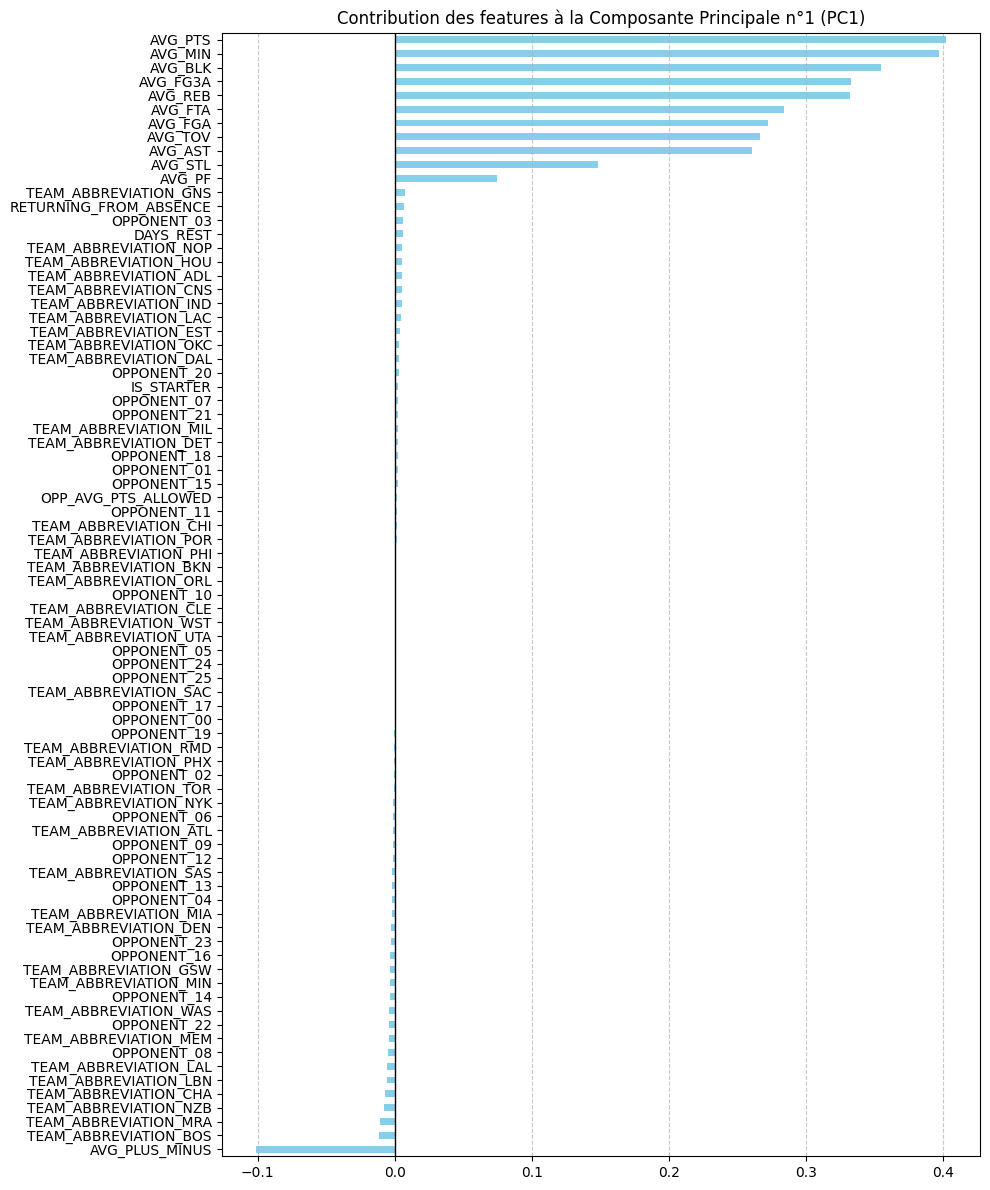

✅ Graphique sauvegardé dans /plots. Dimensions utilisées : 81 features.


In [14]:
import matplotlib.pyplot as plt

# 1. On récupère les noms générés par l'encodeur
feature_names = encoder.get_feature_names_out()

# 2. On vérifie la taille des composants de la PCA
# pca.components_ a une forme (n_composantes, n_features_entree)
n_features_in_pca = pca.components_.shape[1]

# 3. Sécurité : On s'assure que les index correspondent aux données de la PCA
# Si l'encodeur a 93 colonnes mais la PCA n'en a vu que 81, on retaille la liste des noms
feature_names_adjusted = feature_names[:n_features_in_pca]

# 4. Création du DataFrame des loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names_adjusted
)

# 5. Visualisation de la PC1
plt.figure(figsize=(10, 12))
loadings['PC1'].sort_values().plot(kind='barh', color='skyblue')
plt.title("Contribution des features à la Composante Principale n°1 (PC1)")
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# SAUVEGARDE pour ton dossier plots (consigne du jour !)
plt.savefig("../plots/pca_loadings_pc1.png")
plt.show()

print(f"✅ Graphique sauvegardé dans /plots. Dimensions utilisées : {n_features_in_pca} features.")

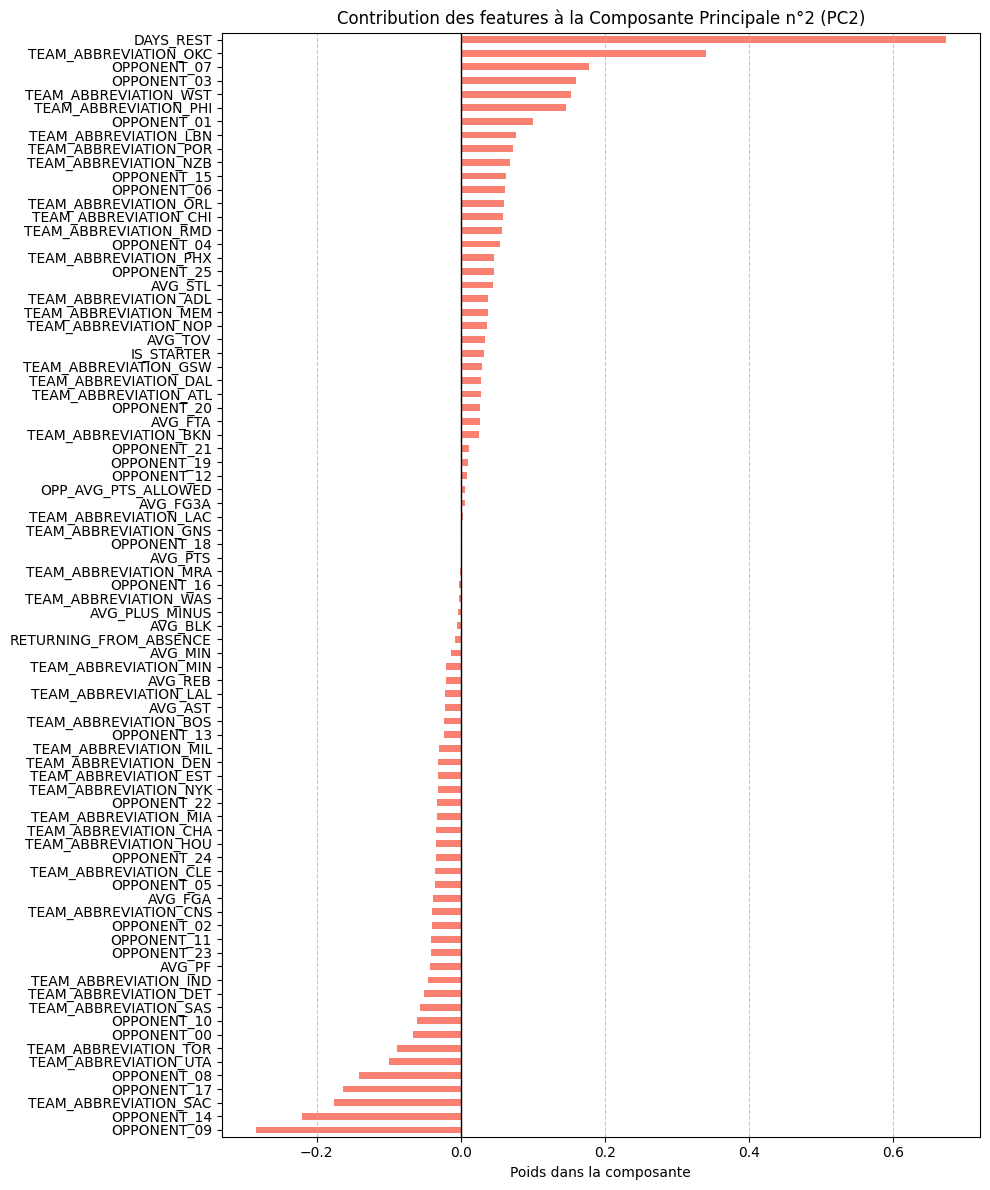

In [15]:
plt.figure(figsize=(10, 12))
loadings['PC2'].sort_values().plot(kind='barh', color='salmon') # Couleur différente pour différencier
plt.title("Contribution des features à la Composante Principale n°2 (PC2)")
plt.xlabel("Poids dans la composante")
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

"Pour m'assurer que les variables de volume (minutes, tirs) n'écrasaient pas mon modèle, j'ai analysé les deux premières composantes de ma PCA.

La PC1 gère effectivement la hiérarchie titulaire/remplaçant (le volume).

La PC2, elle, décompose le profil technique : elle oppose les joueurs intérieurs (rebonds/contres) aux joueurs extérieurs (3-points/passes).

En combinant ces axes, mon Random Forest est capable de comprendre qu'un tir tenté par un pivot n'a pas la même probabilité de réussite ou la même valeur qu'un tir à 3-points d'un meneur. C'est ainsi que j'évite un modèle simpliste."

Chargement des données pour l'EDA...
🚀 Récupération des données via PlayerGameLogs...
✅ Saison 2022-23 récupérée.
✅ Saison 2023-24 récupérée.
✅ Saison 2024-25 récupérée.
📈 Calcul des moyennes mobiles...
🛡️ Analyse des adversaires...
🌍 Enrichissement contextuel...
💾 Nouveau fichier sauvegardé : data/nba_raw_data.csv
✅ Dataset prêt ! (89435 lignes)


C:\Users\robin\AppData\Local\Temp\ipykernel_19316\468416809.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LOCATION', y='PTS', data=df_eda, palette="Set2")
C:\Users\robin\AppData\Local\Temp\ipykernel_19316\468416809.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DAY_OF_WEEK', y='PTS', data=df_eda, order=order_days, estimator=np.mean, errorbar=None, palette="viridis")


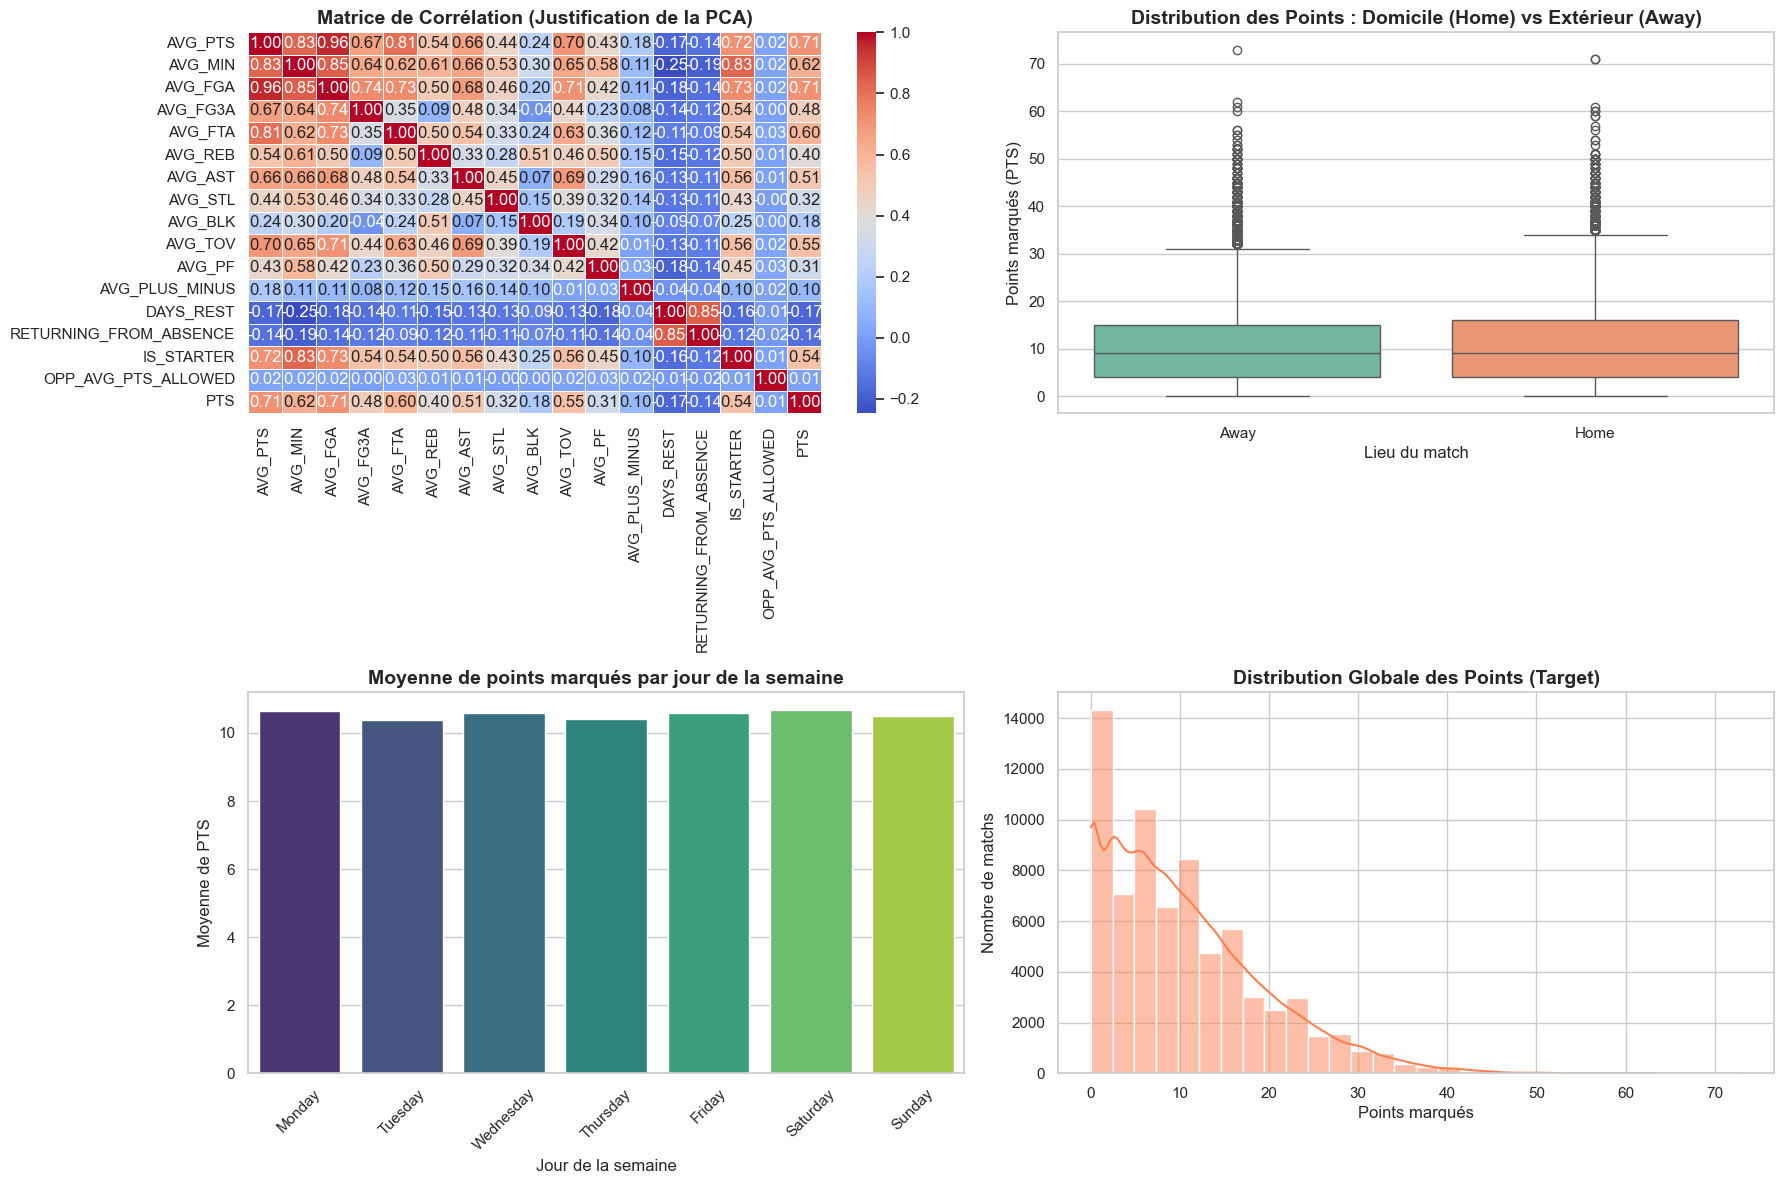

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# On importe ta fonction pour récupérer les données propres
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data import load_dataset_split

# 1. Chargement des données
print("Chargement des données pour l'EDA...")
X_train, X_test, y_train, y_test = load_dataset_split()

# On rassemble X et y pour les graphiques
df_eda = X_train.copy()
df_eda['PTS'] = y_train

# Paramètres de style pour faire "Pro"
sns.set_theme(style="whitegrid", palette="muted")
fig = plt.figure(figsize=(18, 12))

# --- GRAPHIQUE 1 : La Matrice de Corrélation (Heatmap) ---
# Pourquoi ? Pour prouver au prof qu'on avait BESOIN de faire une PCA. 
# On va montrer que des variables comme FGA (tirs tentés) et MIN (minutes) sont très corrélées.
plt.subplot(2, 2, 1)
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
correlation_matrix = df_eda[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation (Justification de la PCA)", fontsize=14, fontweight='bold')

# --- GRAPHIQUE 2 : L'impact du Lieu (Home vs Away) ---
# Pourquoi ? Pour justifier notre Feature Engineering. On montre si jouer à domicile change les points.
plt.subplot(2, 2, 2)
sns.boxplot(x='LOCATION', y='PTS', data=df_eda, palette="Set2")
plt.title("Distribution des Points : Domicile (Home) vs Extérieur (Away)", fontsize=14, fontweight='bold')
plt.xlabel("Lieu du match")
plt.ylabel("Points marqués (PTS)")

# --- GRAPHIQUE 3 : Les points selon les Jours de la semaine ---
# Pourquoi ? Pour justifier l'extraction de la date (DAY_OF_WEEK).
plt.subplot(2, 2, 3)
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x='DAY_OF_WEEK', y='PTS', data=df_eda, order=order_days, estimator=np.mean, errorbar=None, palette="viridis")
plt.title("Moyenne de points marqués par jour de la semaine", fontsize=14, fontweight='bold')
plt.xlabel("Jour de la semaine")
plt.ylabel("Moyenne de PTS")
plt.xticks(rotation=45)

# --- GRAPHIQUE 4 : Distribution de la Target ---
# Pourquoi ? Pour montrer qu'on a bien identifié l'asymétrie des scores NBA.
plt.subplot(2, 2, 4)
sns.histplot(df_eda['PTS'], bins=30, kde=True, color='coral')
plt.title("Distribution Globale des Points (Target)", fontsize=14, fontweight='bold')
plt.xlabel("Points marqués")
plt.ylabel("Nombre de matchs")

plt.tight_layout()
plt.show()

C:\Users\robin\AppData\Local\Temp\ipykernel_19316\639814646.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_pts_opp.index, y=avg_pts_opp.values, palette="magma")
C:\Users\robin\AppData\Local\Temp\ipykernel_19316\639814646.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='LOCATION', y='PTS', data=df_eda, palette="Set2", inner="quartile")


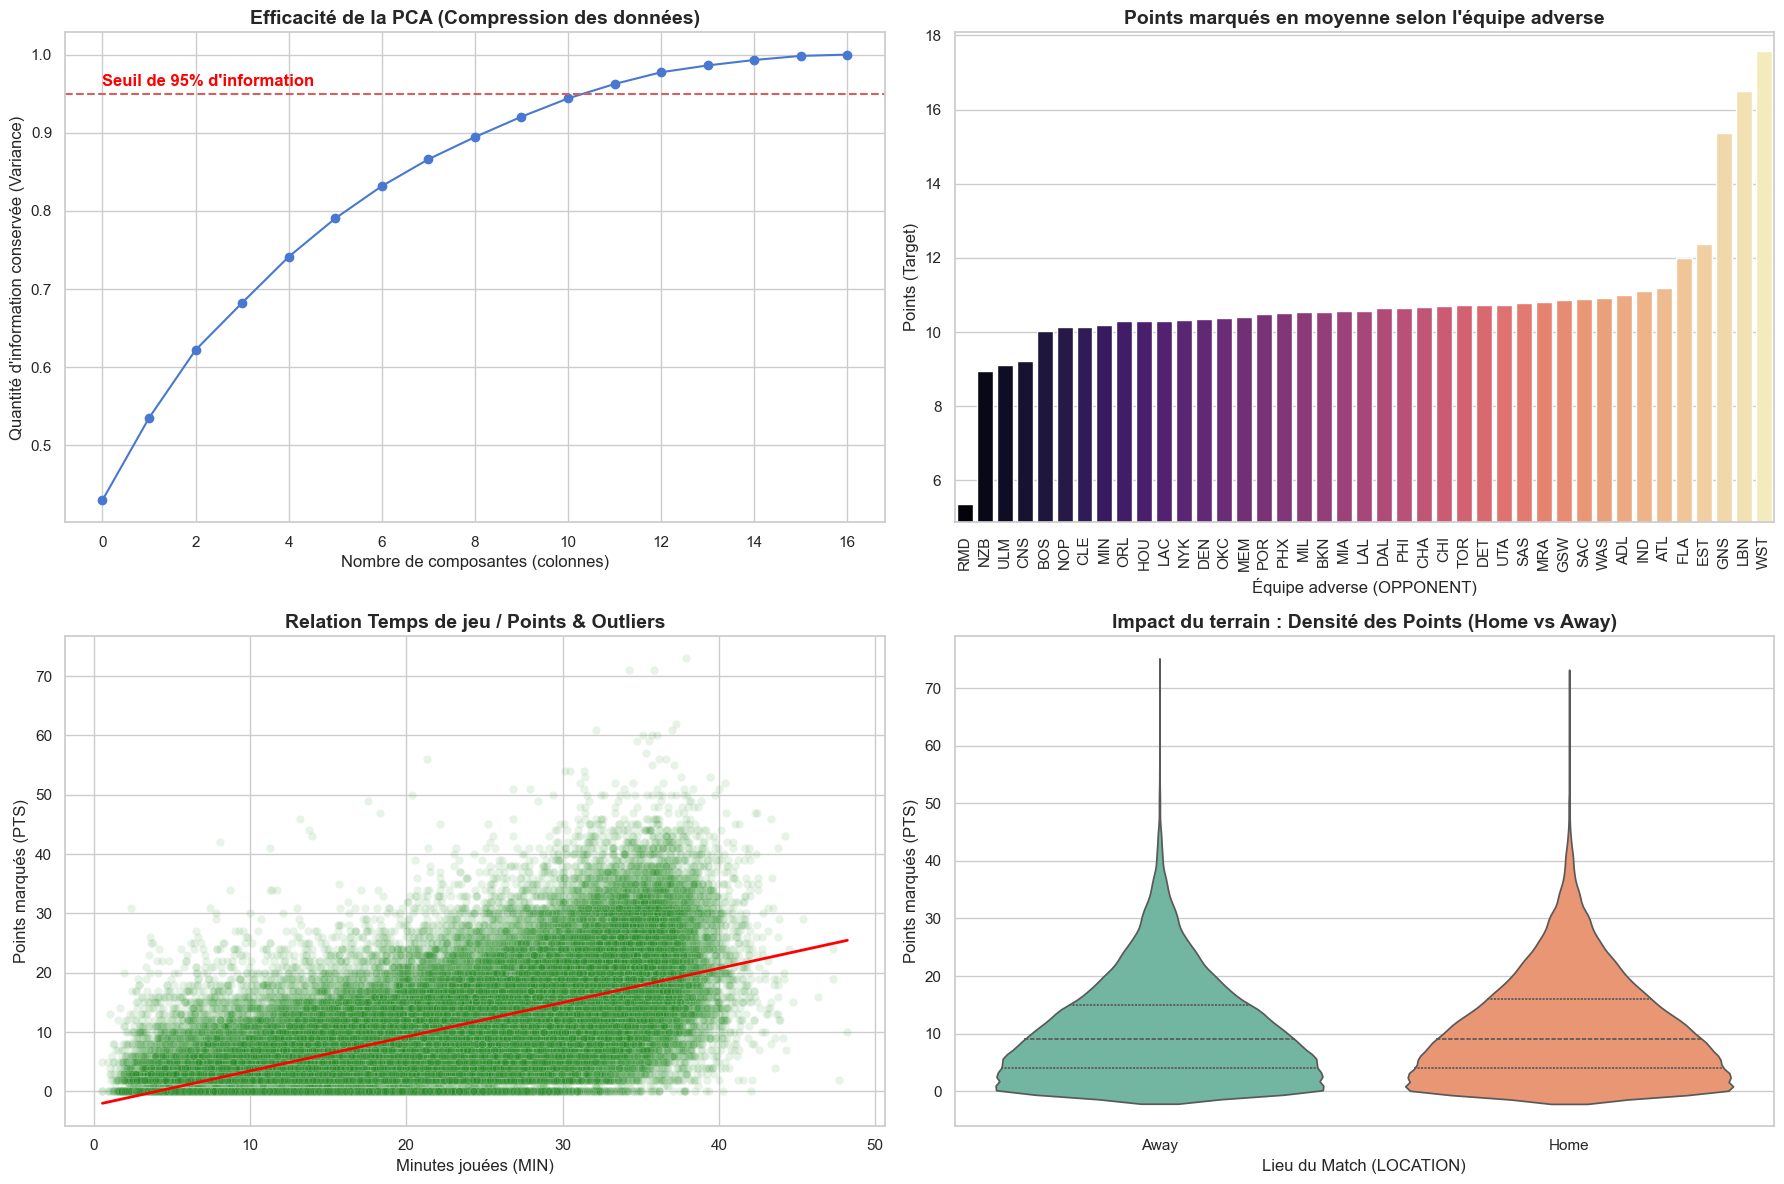

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(18, 12))

# --- GRAPHIQUE 1 (en haut à gauche) : La courbe de la PCA ---
plt.subplot(2, 2, 1)
numeric_features = df_eda.select_dtypes(include=[np.number]).columns
X_num_scaled = StandardScaler().fit_transform(df_eda[numeric_features])
pca_vis = PCA().fit(X_num_scaled)

plt.plot(np.cumsum(pca_vis.explained_variance_ratio_), marker='o', linestyle='-', color='b')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.text(0, 0.96, 'Seuil de 95% d\'information', color='red', fontsize=12, fontweight='bold')
plt.title("Efficacité de la PCA (Compression des données)", fontsize=14, fontweight='bold')
plt.xlabel('Nombre de composantes (colonnes)')
plt.ylabel('Quantité d\'information conservée (Variance)')

# --- GRAPHIQUE 2 (en haut à droite) : L'importance de l'Adversaire ---
plt.subplot(2, 2, 2)
avg_pts_opp = df_eda.groupby('OPPONENT')['PTS'].mean().sort_values()
sns.barplot(x=avg_pts_opp.index, y=avg_pts_opp.values, palette="magma")
plt.title("Points marqués en moyenne selon l'équipe adverse", fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.xlabel('Équipe adverse (OPPONENT)')
plt.ylabel('Points (Target)')
plt.ylim(min(avg_pts_opp.values) - 0.5, max(avg_pts_opp.values) + 0.5)

# --- GRAPHIQUE 3 (en bas à gauche) : Outliers et Temps de jeu ---
plt.subplot(2, 2, 3)
sns.scatterplot(x='AVG_MIN', y='PTS', data=df_eda, alpha=0.1, color='forestgreen')
sns.regplot(x='AVG_MIN', y='PTS', data=df_eda, scatter=False, color='red', line_kws={"linewidth": 2})
plt.title("Relation Temps de jeu / Points & Outliers", fontsize=14, fontweight='bold')
plt.xlabel('Minutes jouées (MIN)')
plt.ylabel('Points marqués (PTS)')

# --- GRAPHIQUE 4 (en bas à droite) : Densité Domicile vs Extérieur ---
# Pourquoi ? Justifie l'extraction de 'LOCATION' avec un visuel très riche (Violin Plot).
plt.subplot(2, 2, 4)
sns.violinplot(x='LOCATION', y='PTS', data=df_eda, palette="Set2", inner="quartile")
plt.title("Impact du terrain : Densité des Points (Home vs Away)", fontsize=14, fontweight='bold')
plt.xlabel('Lieu du Match (LOCATION)')
plt.ylabel('Points marqués (PTS)')

plt.tight_layout()
plt.show()